In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [164]:
df = pd.read_csv('dataset_2022_clean.csv')

In [165]:
df.Severity.value_counts()

Severity
2    1603346
3      77957
4      43274
1      37875
Name: count, dtype: int64

C:\Users\frans\AppData\Local\Temp\ipykernel_21624\2203351291.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




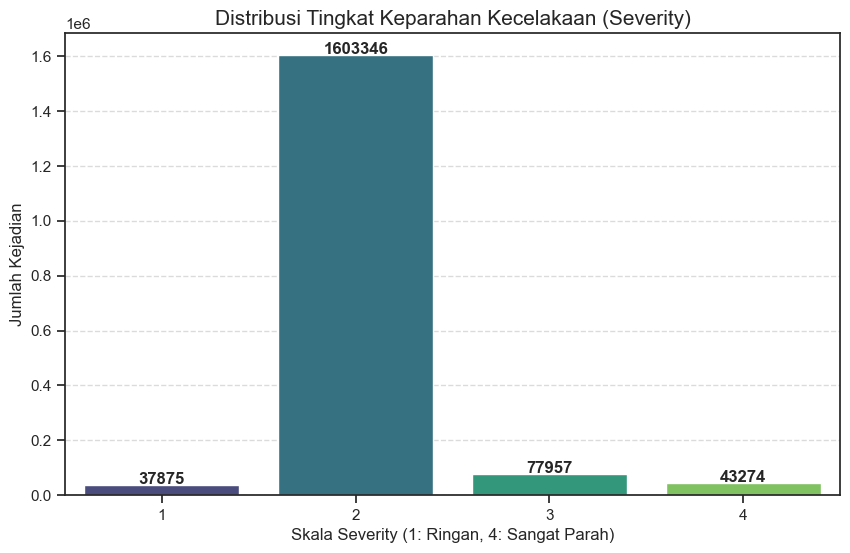

In [166]:
# Membuat bar chart
severity_counts = df['Severity'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=severity_counts.index, y=severity_counts.values, palette='viridis')

plt.title('Distribusi Tingkat Keparahan Kecelakaan (Severity)', fontsize=15)
plt.xlabel('Skala Severity (1: Ringan, 4: Sangat Parah)', fontsize=12)
plt.ylabel('Jumlah Kejadian', fontsize=12)

for i, v in enumerate(severity_counts.values):
    plt.text(i, v + 5000, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# EDA Tahap 1

In [167]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Tahun
0,A-512230,Source2,1,2022-09-08 05:49:30,2022-09-08 06:34:53,41.946796,-88.208092,NaN,NaN,0.00,...,False,False,False,True,False,Night,Night,Day,Day,2022
1,A-512231,Source2,1,2022-09-08 02:02:05,2022-09-08 04:31:32,34.521172,-117.958076,NaN,NaN,0.00,...,False,False,False,False,False,Night,Night,Night,Night,2022
2,A-512232,Source2,1,2022-09-08 05:14:12,2022-09-08 07:38:17,37.542839,-77.441780,NaN,NaN,0.00,...,False,False,False,True,False,Night,Night,Night,Night,2022
3,A-512233,Source2,1,2022-09-08 06:22:57,2022-09-08 06:52:42,40.896629,-81.178452,NaN,NaN,0.00,...,False,False,False,False,False,Night,Night,Day,Day,2022
4,A-512234,Source2,2,2022-09-08 06:36:20,2022-09-08 07:05:58,41.409359,-81.644318,NaN,NaN,1.91,...,False,False,False,False,False,Night,Day,Day,Day,2022


In [168]:
df.drop(columns='Tahun', axis=1, inplace=True)
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1762452 entries, 0 to 1762451
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [170]:
# Mencari jumlah missing value tiap kolom
df.isnull().sum()

ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  236182
End_Lng                  236182
Distance(mi)                  0
Description                   0
Street                     7236
City                         65
County                        0
State                         0
Zipcode                     307
Country                       0
Timezone                   1713
Airport_Code               7199
Weather_Timestamp         29595
Temperature(F)            38718
Wind_Chill(F)             54508
Humidity(%)               41107
Pressure(in)              33134
Visibility(mi)            41953
Wind_Direction            48385
Wind_Speed(mph)           48377
Precipitation(in)         64475
Weather_Condition         38688
Amenity                       0
Bump                          0
Crossing

**Hasil Overview**
- Kolom End_Lat dan End_Lng punya jumlah missing value yang sama. Apakah missingnya di baris yang sama?
- Kolom Sunrise_Sunset - Astronomical_Twilight punya jumlah missing value yang sama. Apakah missingnya di baris yang sama?
- Kolom Temperature - Precipitation (kolom numerikal) ada missing value

**Penjelasan Kolom**
- Sunrise_Sunset : indikator siang dan malam (Day == matahari || Night == tidak ada matahari)
- Civil_Twilight : kondisi cahaya paling terang. momen krusial pengemudi bingung menyalakan lampu atau tidak
- Nautical_Twilight : kondisi cahaya sangat minim
- Astronomical_Twilight: langit sudah gelap total
Karena US memiliki 4 musim, kondisi langit di musim2 tertentu itu berbeda tiap jamnya. Makanya dibikin kolom seperti ini

Ini adalah redundansi data. Kita gunakan Civil_Twilight aja karena ini ambang batas pengelihatan manusia. Kalau true klihatan, kalau false ga kliatan. Ini sering menjadi titik kritis kecelakaan dan bisa memberikan gambaran tentang kegelapan yang dialami pengemudi. 

## Persebaran atau Kondisi Data Sebelum di Impute

In [171]:
# Cek kolom End_Lat dan Start_Lat
df['Lat_Diff'] = abs(df['End_Lat'] - df['Start_Lat'])

correlation = df['Start_Lat'].corr(df['End_Lat'])

same_exact = (df['Start_Lat'] == df['End_Lat']).mean() * 100

print(f"Korelasi Pearson: {correlation:.6f}")


Korelasi Pearson: 0.999991


In [172]:
# Cek kolom End_Lat dan Start_Lat
df['Lng_Diff'] = abs(df['End_Lng'] - df['Start_Lng'])

correlation = df['Start_Lng'].corr(df['End_Lng'])

same_exact = (df['Start_Lng'] == df['End_Lng']).mean() * 100

print(f"Korelasi Pearson: {correlation:.6f}")


Korelasi Pearson: 0.999998


C:\Users\frans\AppData\Local\Temp\ipykernel_21624\1875091167.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




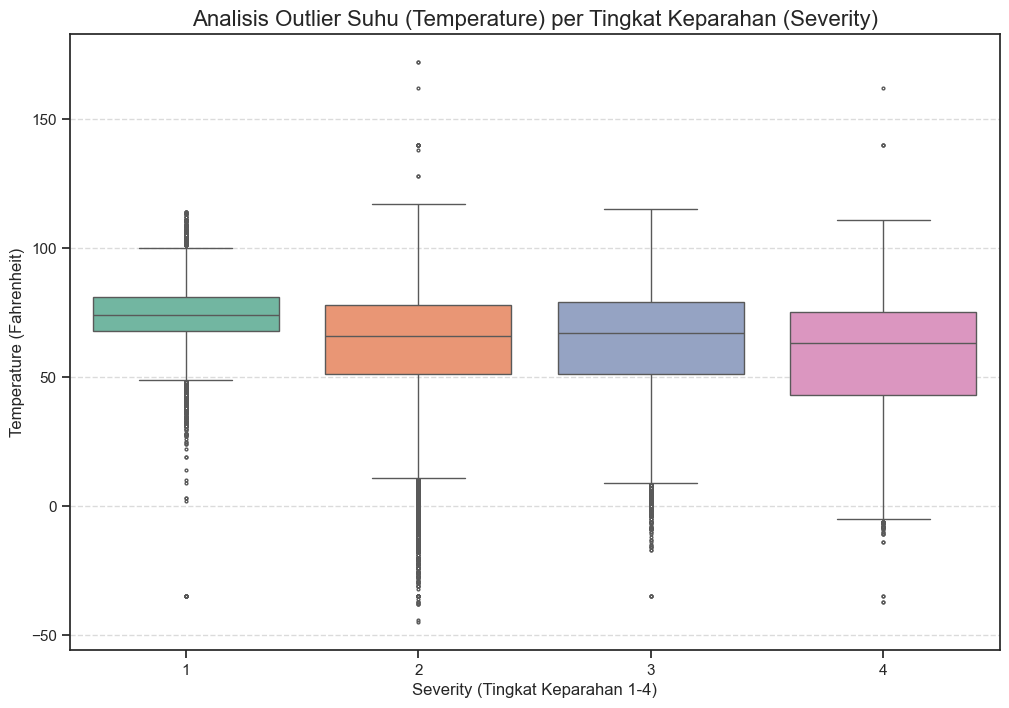

In [173]:
# Visualisasi distribusi data di kolom Temperature
plt.figure(figsize=(12, 8))
sns.set_theme(style="ticks")
sns.boxplot(data=df, x='Severity', y='Temperature(F)', palette='Set2', fliersize=2)

plt.title('Analisis Outlier Suhu (Temperature) per Tingkat Keparahan (Severity)', fontsize=16)
plt.xlabel('Severity (Tingkat Keparahan 1-4)', fontsize=12)
plt.ylabel('Temperature (Fahrenheit)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\frans\AppData\Local\Temp\ipykernel_21624\379137015.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




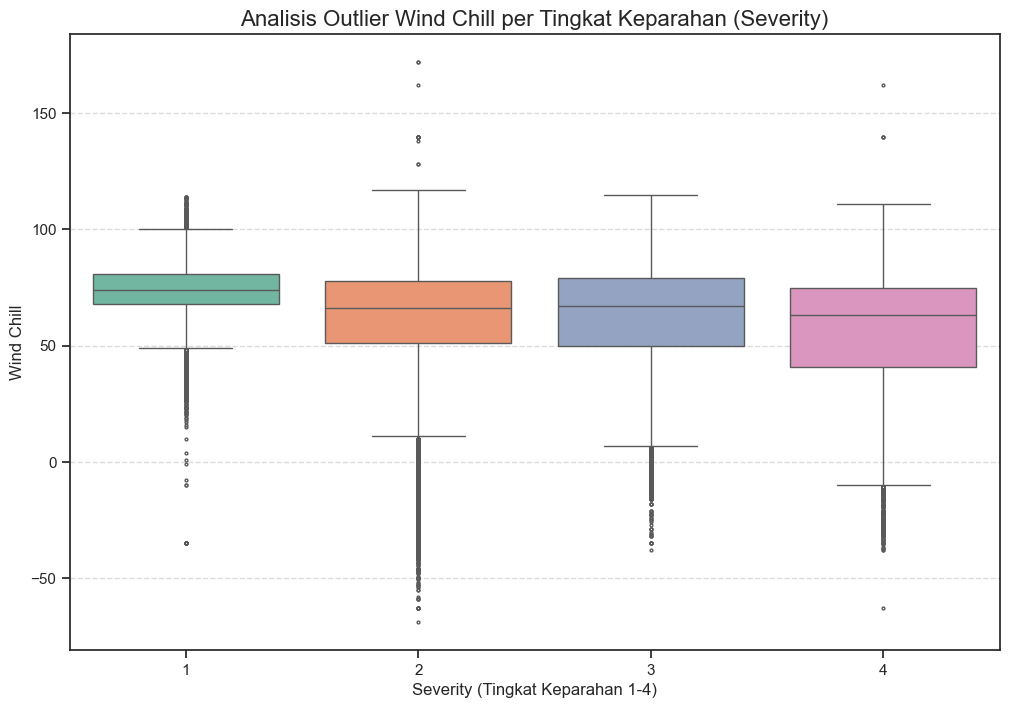

In [174]:
# Visualisasi distribusi data di kolom Wind Chill
plt.figure(figsize=(12, 8))
sns.set_theme(style="ticks")
sns.boxplot(data=df, x='Severity', y='Wind_Chill(F)', palette='Set2', fliersize=2)

plt.title('Analisis Outlier Wind Chill per Tingkat Keparahan (Severity)', fontsize=16)
plt.xlabel('Severity (Tingkat Keparahan 1-4)', fontsize=12)
plt.ylabel('Wind Chill', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\frans\AppData\Local\Temp\ipykernel_21624\1683422783.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




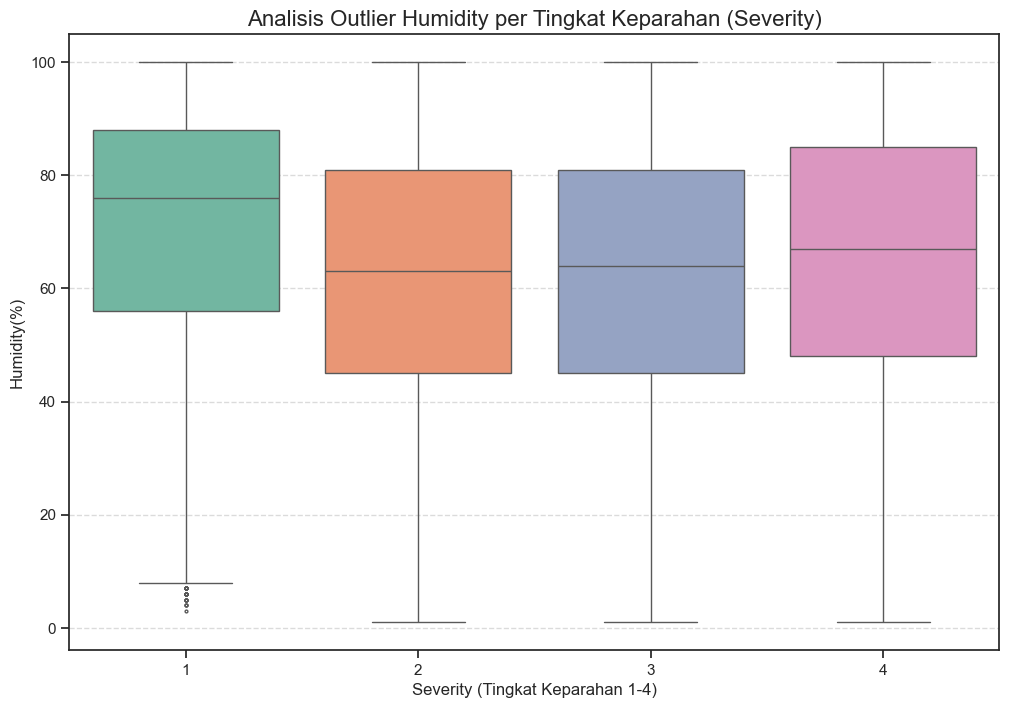

In [175]:
# Visualisasi distribusi data di kolom Humidity
plt.figure(figsize=(12, 8))
sns.set_theme(style="ticks")

sns.boxplot(data=df, x='Severity', y='Humidity(%)', palette='Set2', fliersize=2)
plt.title('Analisis Outlier Humidity per Tingkat Keparahan (Severity)', fontsize=16)
plt.xlabel('Severity (Tingkat Keparahan 1-4)', fontsize=12)
plt.ylabel('Humidity(%)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\frans\AppData\Local\Temp\ipykernel_21624\3846363101.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




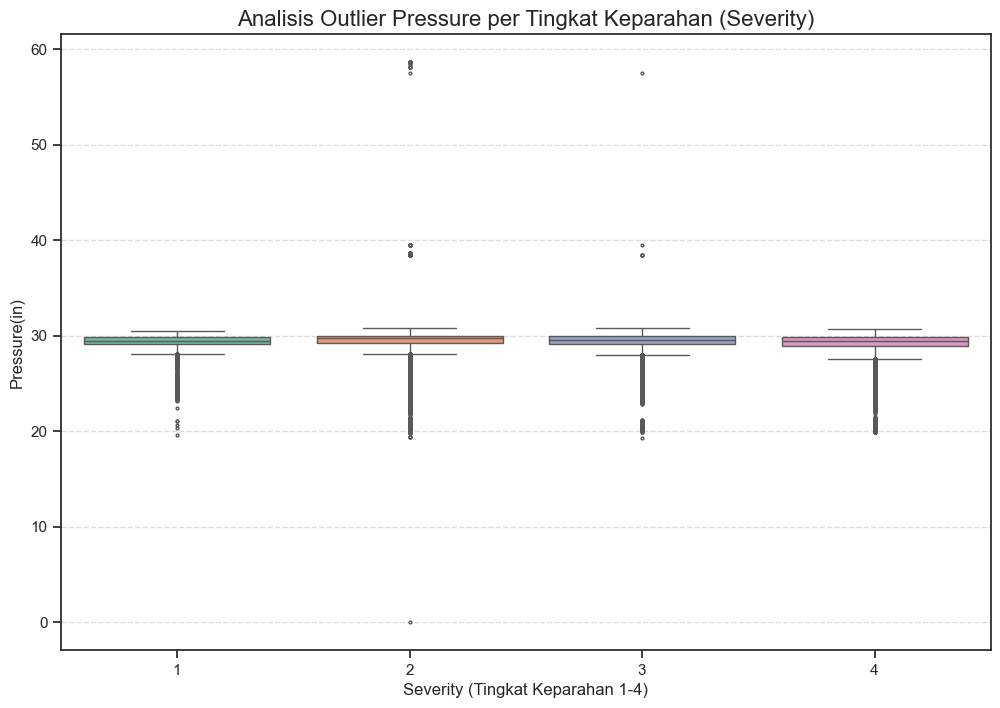

In [176]:
# Visualisasi distribusi data di kolom Pressure
plt.figure(figsize=(12, 8))
sns.set_theme(style="ticks")
sns.boxplot(data=df, x='Severity', y='Pressure(in)', palette='Set2', fliersize=2)

plt.title('Analisis Outlier Pressure per Tingkat Keparahan (Severity)', fontsize=16)
plt.xlabel('Severity (Tingkat Keparahan 1-4)', fontsize=12)
plt.ylabel('Pressure(in)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\frans\AppData\Local\Temp\ipykernel_21624\3364341984.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




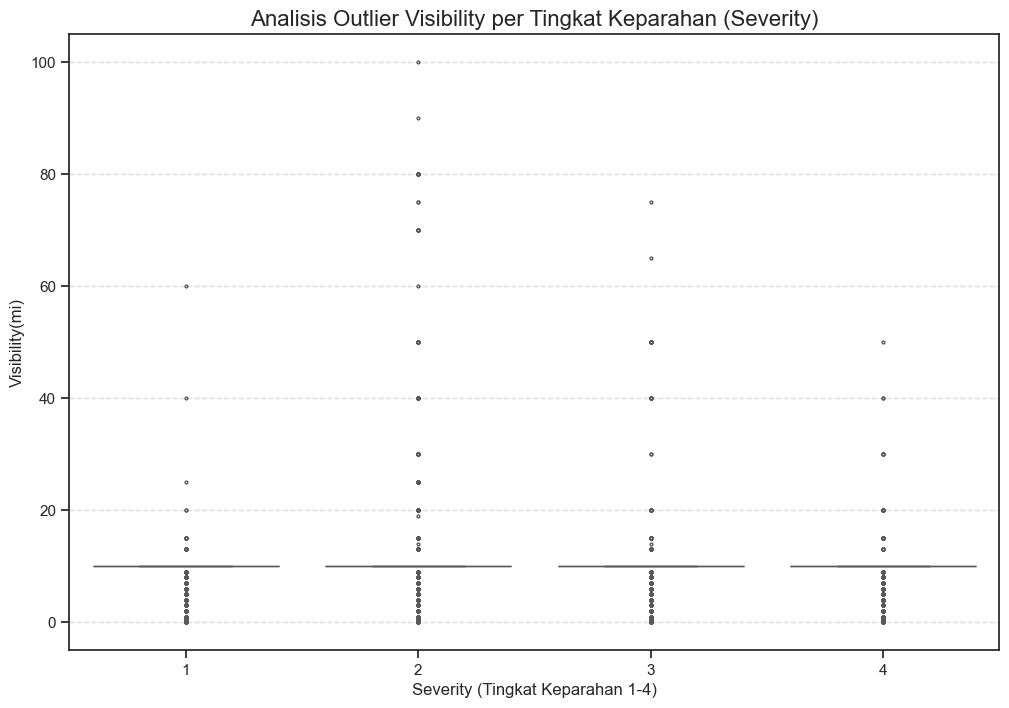

In [177]:
# Visualisasi distribusi data di kolom Visibility
plt.figure(figsize=(12, 8))
sns.set_theme(style="ticks")

sns.boxplot(data=df, x='Severity', y='Visibility(mi)', palette='Set2', fliersize=2)

plt.title('Analisis Outlier Visibility per Tingkat Keparahan (Severity)', fontsize=16)
plt.xlabel('Severity (Tingkat Keparahan 1-4)', fontsize=12)
plt.ylabel('Visibility(mi)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\frans\AppData\Local\Temp\ipykernel_21624\4267055259.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




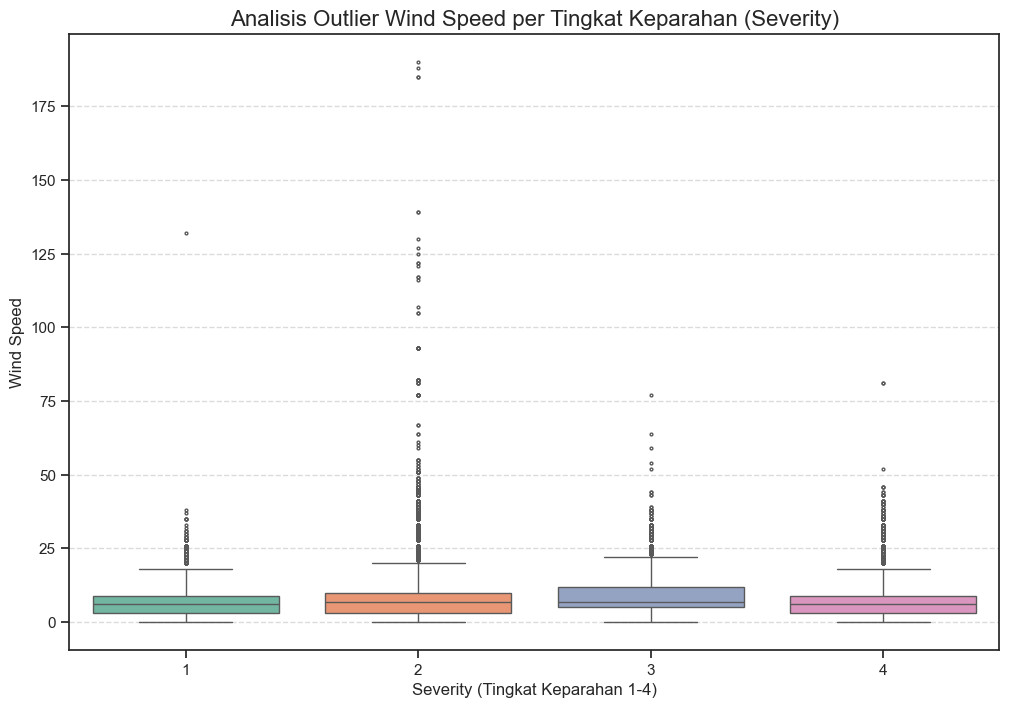

In [178]:
# Visualisasi distribusi data di kolom Precipitation
plt.figure(figsize=(12, 8))
sns.set_theme(style="ticks")

sns.boxplot(data=df, x='Severity', y='Wind_Speed(mph)', palette='Set2', fliersize=2)

plt.title('Analisis Outlier Wind Speed per Tingkat Keparahan (Severity)', fontsize=16)
plt.xlabel('Severity (Tingkat Keparahan 1-4)', fontsize=12)
plt.ylabel('Wind Speed', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\frans\AppData\Local\Temp\ipykernel_21624\2609255539.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




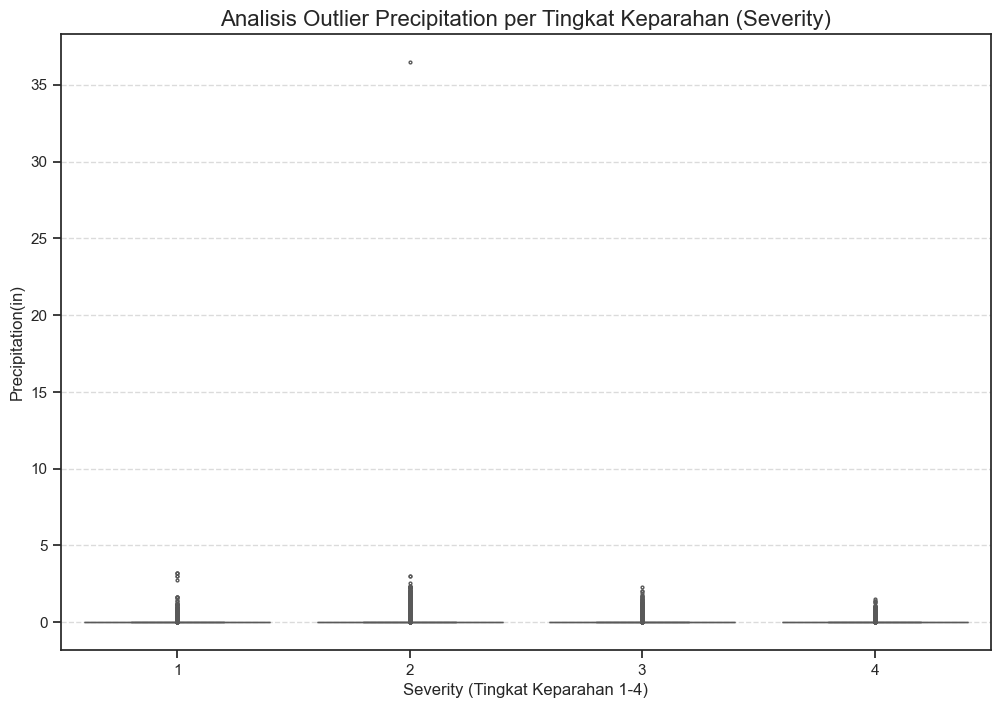

In [179]:
# Visualisasi distribusi data di kolom Precipitation
plt.figure(figsize=(12, 8))
sns.set_theme(style="ticks")

sns.boxplot(data=df, x='Severity', y='Precipitation(in)', palette='Set2', fliersize=2)

plt.title('Analisis Outlier Precipitation per Tingkat Keparahan (Severity)', fontsize=16)
plt.xlabel('Severity (Tingkat Keparahan 1-4)', fontsize=12)
plt.ylabel('Precipitation(in)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Melalui visualisasi tersebut, dapat dilihat bahwa:**
- Semua kolom memiliki outlier yang tidak wajar, kecuali kolom Humidity. Kita bisa mempertimbangkan untuk impute dengan groupby menggunakan Weather_Condition dengan median

In [180]:
unique_counts = df.nunique().sort_values(ascending=False)

unique_df = unique_counts.reset_index()
unique_df.columns = ['Nama Kolom', 'Jumlah Nilai Unik']
print("Jumlah Nilai Unik per Kolom (Urutan Terbanyak):")
print(unique_df)

Jumlah Nilai Unik per Kolom (Urutan Terbanyak):
               Nama Kolom  Jumlah Nilai Unik
0                      ID            1762452
1                End_Time            1459975
2              Start_Time            1012755
3             Description             963747
4               Start_Lng             880214
5               Start_Lat             869621
6                 End_Lng             721831
7                 End_Lat             716006
8                 Zipcode             304674
9                Lng_Diff             183405
10                 Street             165000
11               Lat_Diff             161955
12      Weather_Timestamp             145671
13           Distance(mi)              17400
14                   City              10394
15           Airport_Code               1916
16                 County               1650
17           Pressure(in)               1030
18      Precipitation(in)                196
19          Wind_Chill(F)                181
20     

<Axes: >

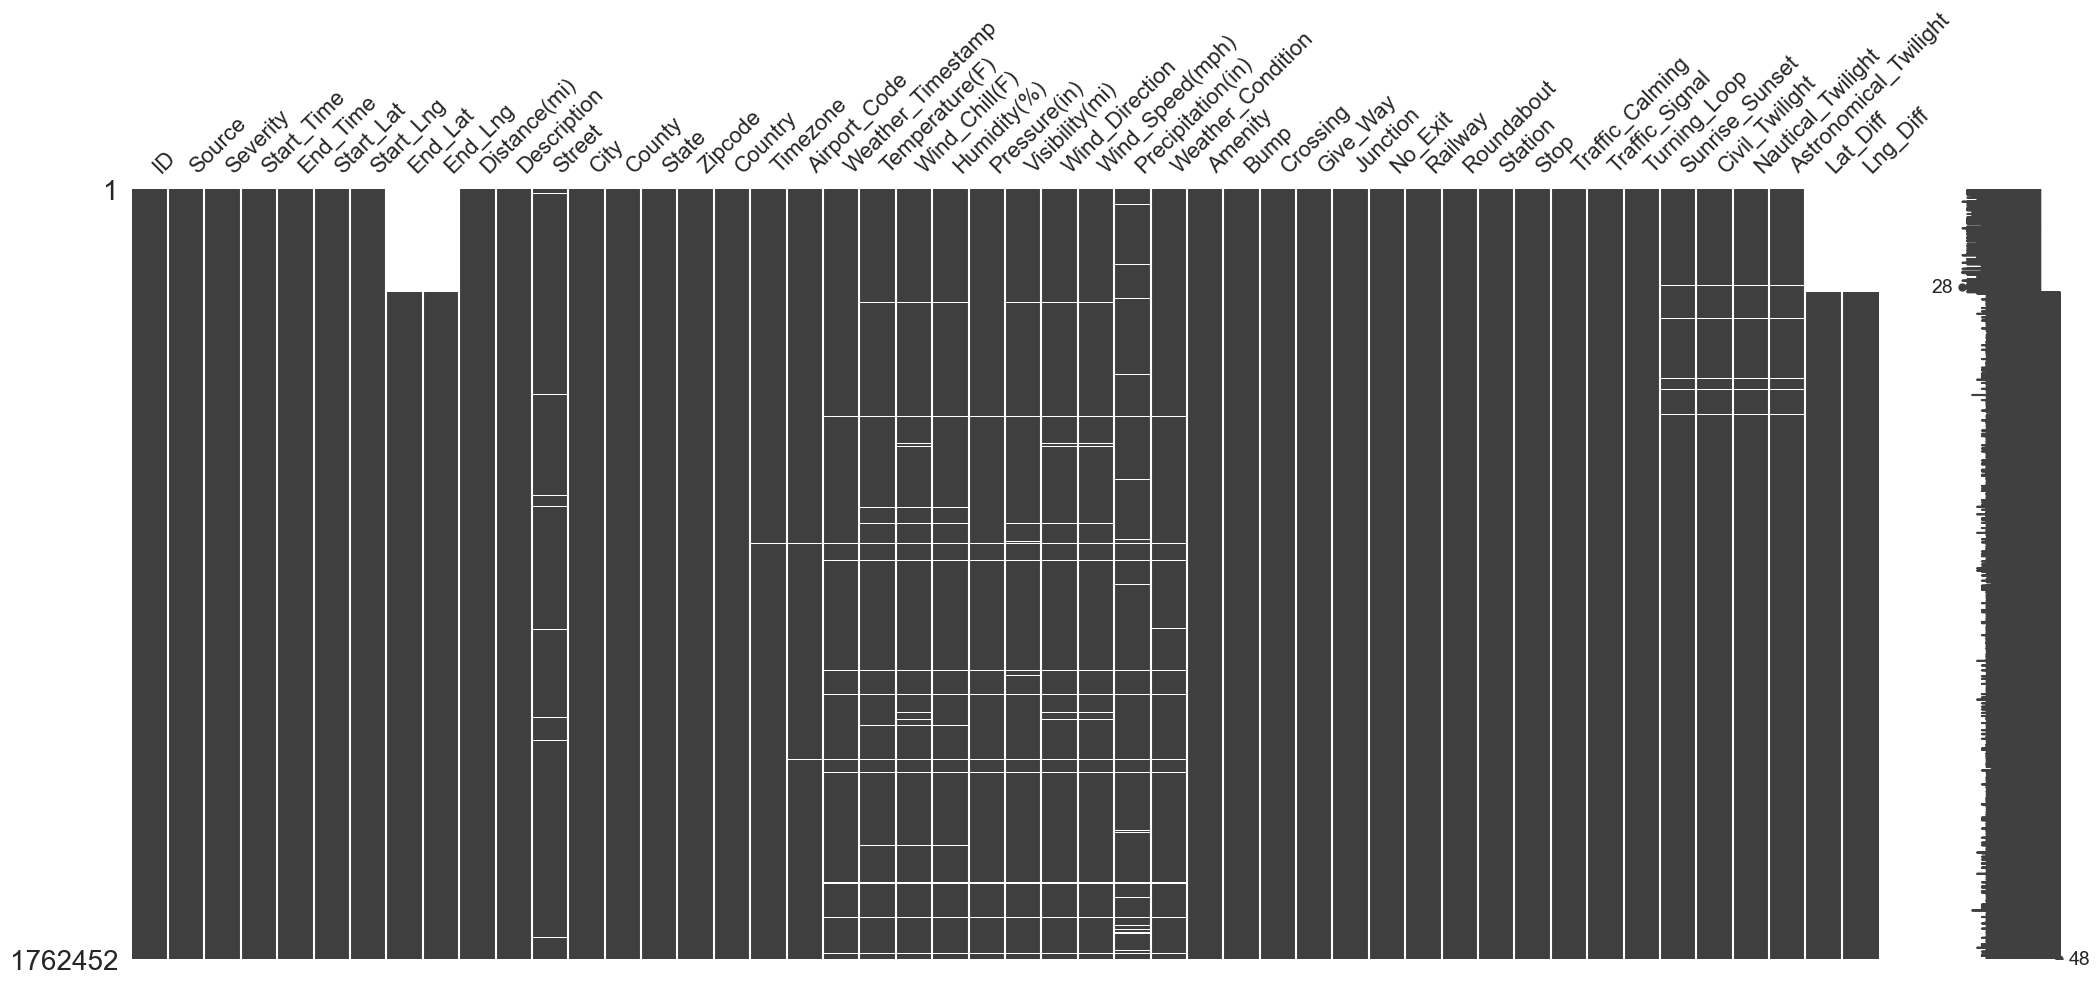

In [181]:
!pip install missingno

import missingno as msno
msno.matrix(df)

**Jawaban dari Hasil Overview:**
- Kolom Start_Lat dan End_Lat sangat identik. Kita bisa drop kolom End_Lat dan End_Lng karena mereka missing di baris yang sama
- Drop 4 kolom terbawah kecuali Civil_Twilight
- Outlier di kolom numerikal GILAA BGT

**Setelah melihat missing value, tipe data, nilai unik, dan nama dari setiap kolom, ada beberapa to do yang harus dikerjakan:**
- Mengubah variabel time-time jadi datetype
- Sederhanakan kolom `Weather_Condition`
- Impute `Weather_Condition` based on angka numerikal
- Persempit kategori untuk kolom `Weather_Condition` dan `Wind Direction` karena dia berjumlah 108 nilai unik
- Drop `Country` dan `Turning_Loop` karena hanya memiliki 1 nilai
- Drop `ID`, `Source` karena tidak bernilai untuk sebuah model
- Impute kolom `Temperature(F)`, `Humidity(%)`, `Pressure(in)` `Visibility(mi)`, `Precipitation(in)` dan `Wind_Speed(mph)` (kolom numerikal) di-impute berdasarkan `Weather_Condition`
- Cek korelasi kolom `Temperature` dan `Wind_Chill` karena satuannya sama-sama Farenheit
- Buat Geoplot dari kolom `State`
- Drop kolom `Description` karena ada **408,146** nilai unik
- Drop kolom `Street` terdiri dari **88,272** nilai unik dan berpotensi menyebabkan overfitting
- Drop kolom `Zipcode` karena berpotensi menyebabkan overfitting
- Drop kolom `Airport_Code`, `Weather_Timestamp`



## Preprocessing Tahap 1

In [182]:
# Mengubah tipe data ke datetype
cols_to_fix = ['Start_Time', 'End_Time', 'Weather_Timestamp']

for col in cols_to_fix:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(df[cols_to_fix].dtypes)
df[cols_to_fix].head()

Start_Time           datetime64[ns]
End_Time             datetime64[ns]
Weather_Timestamp    datetime64[ns]
dtype: object


,Start_Time,End_Time,Weather_Timestamp
0,2022-09-08 05:49:30,2022-09-08 06:34:53,2022-09-08 05:52:00
1,2022-09-08 02:02:05,2022-09-08 04:31:32,2022-09-08 01:53:00
2,2022-09-08 05:14:12,2022-09-08 07:38:17,2022-09-08 05:16:00
3,2022-09-08 06:22:57,2022-09-08 06:52:42,2022-09-08 06:51:00
4,2022-09-08 06:36:20,2022-09-08 07:05:58,2022-09-08 06:53:00


In [183]:
# Mencari selisih antara Weather_Timestamp dengan Start_Time
delta_minutes = (df['Start_Time'] - df['Weather_Timestamp']).dt.total_seconds().abs() / 60

exact_match = (df['Start_Time'] == df['Weather_Timestamp']).mean() * 100
within_15_min = (delta_minutes <= 15).mean() * 100
average_diff = delta_minutes.mean()
median_diff = delta_minutes.median()

summary_metrics = pd.DataFrame({
    'Metrik Analisis': [
        'Kecocokan Tepat (Exact Match)', 
        'Selisih <= 15 Menit', 
        'Rata-rata Selisih (MAE)', 
        'Median Selisih'
    ],
    'Nilai': [
        f"{exact_match:.2f}%", 
        f"{within_15_min:.2f}%", 
        f"{average_diff:.2f} Menit", 
        f"{median_diff:.2f} Menit"
    ]
})
print("Analisis Kemiripan Kolom Datetime:")
print(summary_metrics.to_markdown(index=False))
timestamp_corr = df['Start_Time'].view('int64').corr(df['Weather_Timestamp'].view('int64'))
print(f"\nKorelasi Linear (Unix Scale): {timestamp_corr:.4f}")

Analisis Kemiripan Kolom Datetime:
| Metrik Analisis               | Nilai       |
|:------------------------------|:------------|
| Kecocokan Tepat (Exact Match) | 0.92%       |
| Selisih <= 15 Menit           | 59.78%      |
| Rata-rata Selisih (MAE)       | 16.13 Menit |
| Median Selisih                | 11.13 Menit |

Korelasi Linear (Unix Scale): -0.0068


C:\Users\frans\AppData\Local\Temp\ipykernel_21624\689963208.py:25: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.

C:\Users\frans\AppData\Local\Temp\ipykernel_21624\689963208.py:25: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



In [184]:
# Simplifikasi kolom Weather_Condition
df['Weather_Condition'] = df['Weather_Condition'].astype(str).str.lower()

conditions = [
    df['Weather_Condition'].str.contains('thunder|t-storm|tornado|squalls|hail', na=False),
    df['Weather_Condition'].str.contains('snow|sleet|ice|wintry|grains', na=False),
    df['Weather_Condition'].str.contains('rain|drizzle|shower|mist', na=False),
    df['Weather_Condition'].str.contains('fog|haze|smoke|mist', na=False),
    df['Weather_Condition'].str.contains('cloudy|overcast|scatters', na=False),
    df['Weather_Condition'].str.contains('fair|clear', na=False),
    df['Weather_Condition'].str.contains('dust|sand|windy|ash', na=False)
]

choices = ['Storm', 'Snow', 'Rain', 'Fog', 'Cloudy', 'Clear', 'Windy/Dust']

df['Weather_Condition'] = np.select(conditions, choices, default='Other')

df.loc[df['Weather_Condition'] == 'nan', 'Weather_Condition'] = np.nan

In [185]:
# Impute Weather_Condition based on Temperature and Precipitation

df['Temperature(F)'] = pd.to_numeric(df['Temperature(F)'], errors='coerce')
df['Precipitation(in)'] = pd.to_numeric(df['Precipitation(in)'], errors='coerce')
df['Visibility(mi)'] = pd.to_numeric(df['Visibility(mi)'], errors='coerce')

mask_missing = df['Weather_Condition'].isna()

conditions = [
    # STORM: Jika ada presipitasi tinggi dan suhu hangat (indikasi badai hujan)
    mask_missing & (df['Precipitation(in)'] > 0.3),
    
    # SNOW: Jika ada presipitasi dan suhu sangat dingin
    mask_missing & (df['Precipitation(in)'] > 0) & (df['Temperature(F)'] <= 28),
    
    # RAIN: Jika ada presipitasi dan suhu di atas beku
    mask_missing & (df['Precipitation(in)'] > 0) & (df['Temperature(F)'] > 28),
    
    # FOG: Jika tidak ada hujan tapi jarak pandang sangat rendah
    mask_missing & (df['Precipitation(in)'] == 0) & (df['Visibility(mi)'] <= 1),
    
    # CLEAR: Jika tidak ada hujan dan jarak pandang sangat luas
    mask_missing & (df['Precipitation(in)'] == 0) & (df['Visibility(mi)'] >= 7),
    
    # CLOUDY: Jika tidak ada hujan tapi jarak pandang agak terbatas (mendung/haze)
    mask_missing & (df['Precipitation(in)'] == 0) & (df['Visibility(mi)'].between(1.1, 6.9))
]

choices = [
    'Storm', 
    'Snow', 
    'Rain', 
    'Fog', 
    'Clear', 
    'Cloudy'
]

df['Weather_Condition'] = np.select(conditions, choices, default=df['Weather_Condition'])


In [186]:
missing = df.Weather_Condition.isnull().sum()
print(missing)

0


In [187]:
# Simplifikasi kolom Wind_Direction
df.loc[df['Wind_Direction']=='Calm','Wind_Direction'] = 'CALM'
df.loc[(df['Wind_Direction']=='West')|(df['Wind_Direction']=='WSW')|(df['Wind_Direction']=='WNW'),'Wind_Direction'] = 'W'
df.loc[(df['Wind_Direction']=='South')|(df['Wind_Direction']=='SSW')|(df['Wind_Direction']=='SSE'),'Wind_Direction'] = 'S'
df.loc[(df['Wind_Direction']=='North')|(df['Wind_Direction']=='NNW')|(df['Wind_Direction']=='NNE'),'Wind_Direction'] = 'N'
df.loc[(df['Wind_Direction']=='East')|(df['Wind_Direction']=='ESE')|(df['Wind_Direction']=='ENE'),'Wind_Direction'] = 'E'
df.loc[df['Wind_Direction']=='Variable','Wind_Direction'] = 'VAR'

print("Wind Direction after simplification: ", df['Wind_Direction'].unique())
print('Jumlah nilai unik Wind Direction:', df.Wind_Direction.nunique())

Wind Direction after simplification:  ['CALM' 'W' 'N' 'S' nan 'NE' 'E' 'SE' 'NW' 'VAR' 'SW']
Jumlah nilai unik Wind Direction: 10


In [188]:
# Impute kolom City based on modus di County
df['City'] = df.groupby('County')['City'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown City")
)
df['City'] = df['City'].fillna("Unknown City")

In [189]:
# Drop kolom-kolom yang tidak berguna
kolom_sampah = [
    'End_Lat', 'End_Lng', 'Country', 'ID', 'Source', 'Description', 'Street', 'Zipcode', 'Airport_Code', 'Weather_Timestamp', 'Lat_Diff', 'Lng_Diff', 'Sunrise_Sunset', 'Nautical_Twilight', 'Astronomical_Twilight', 'Turning_Loop'
]

df = df.drop(columns=kolom_sampah, errors='ignore')

In [190]:
df.shape

(1762452, 32)

In [191]:
df.isnull().sum()

Severity                  0
Start_Time                0
End_Time             493646
Start_Lat                 0
Start_Lng                 0
Distance(mi)              0
City                      0
County                    0
State                     0
Timezone               1713
Temperature(F)        38718
Wind_Chill(F)         54508
Humidity(%)           41107
Pressure(in)          33134
Visibility(mi)        41953
Wind_Direction        48385
Wind_Speed(mph)       48377
Precipitation(in)     64475
Weather_Condition         0
Amenity                   0
Bump                      0
Crossing                  0
Give_Way                  0
Junction                  0
No_Exit                   0
Railway                   0
Roundabout                0
Station                   0
Stop                      0
Traffic_Calming           0
Traffic_Signal            0
Civil_Twilight        14896
dtype: int64

In [192]:
# Bikin geoplot
import plotly.express as px
state_counts = df['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Total_Accidents']

fig = px.choropleth(state_counts, 
                    locations='State', 
                    locationmode="USA-states", 
                    color='Total_Accidents',
                    scope="usa",
                    color_continuous_scale="Reds",
                    title='Total Kecelakaan Lalu Lintas per Negara Bagian (USA)')

fig.show()

In [198]:
import pandas as pd
import plotly.express as px

state_severity = df.groupby('State')['Severity'].mean().reset_index()

state_counts = df['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Accident_Count']

map_data = pd.merge(state_severity, state_counts, on='State')

print(map_data.sort_values(by='Severity', ascending=False).head())

   State  Severity  Accident_Count
39    SD  2.756757              37
19    ME  2.688073             109
44    VT  2.473684              38
15    KY  2.291928            2713
4     CO  2.275299           20930


In [199]:
fig = px.choropleth(
    map_data, 
    locations='State',            # Kolom berisi kode negara bagian (CA, TX, dll)
    locationmode="USA-states",    # Mode peta Amerika Serikat
    color='Severity',             # Warna berdasarkan rata-rata keparahan
    hover_name='State',           # Munculkan nama state saat di-hover
    hover_data=['Accident_Count'],# Tambahkan jumlah kecelakaan di tooltip
    color_continuous_scale="Reds",# Skala warna (Merah = Tinggi)
    scope="usa",                  # Fokuskan peta hanya pada USA
    title='Rata-rata Severity Kecelakaan per Negara Bagian'
)

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

In [202]:
df.columns

Index(['Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'Distance(mi)', 'City', 'County', 'State', 'Timezone', 'Temperature(F)',
       'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
       'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)',
       'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way',
       'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
       'Traffic_Calming', 'Traffic_Signal', 'Civil_Twilight', 'Duration',
       'Month', 'Hour'],
      dtype='object')

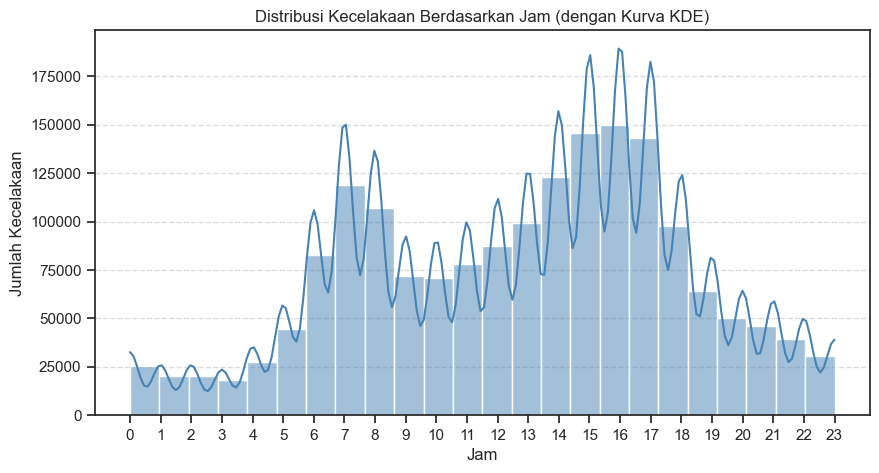

In [203]:
# Distribusi Kecelakaan berdasarkan Waktu
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Hour", bins=24, kde=True, color="steelblue", stat="count")

plt.title("Distribusi Kecelakaan Berdasarkan Jam (dengan Kurva KDE)")
plt.xlabel("Jam")
plt.ylabel("Jumlah Kecelakaan")
plt.xticks(range(0, 24)) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\frans\AppData\Local\Temp\ipykernel_21624\2063745407.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




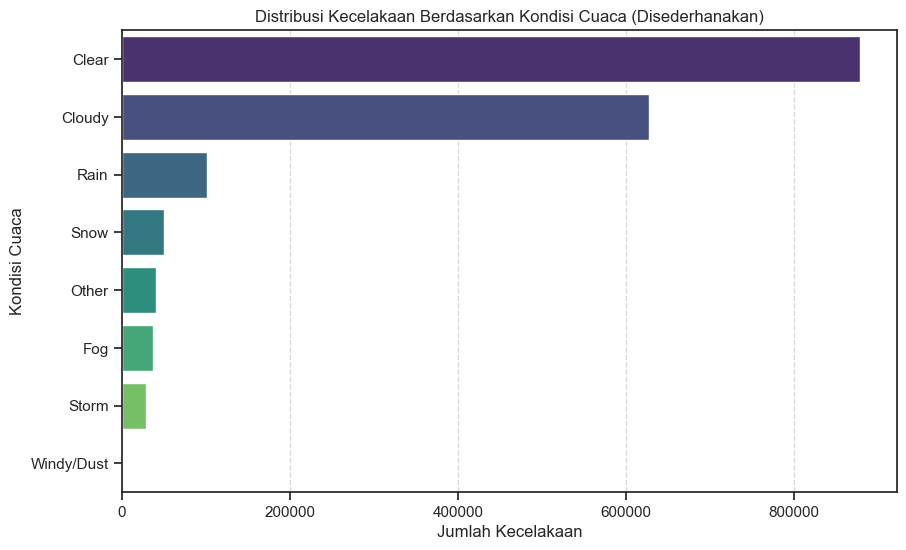

In [205]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Weather_Condition', order=df['Weather_Condition'].value_counts().index, palette='viridis')
plt.title('Distribusi Kecelakaan Berdasarkan Kondisi Cuaca (Disederhanakan)')
plt.xlabel('Jumlah Kecelakaan')
plt.ylabel('Kondisi Cuaca')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

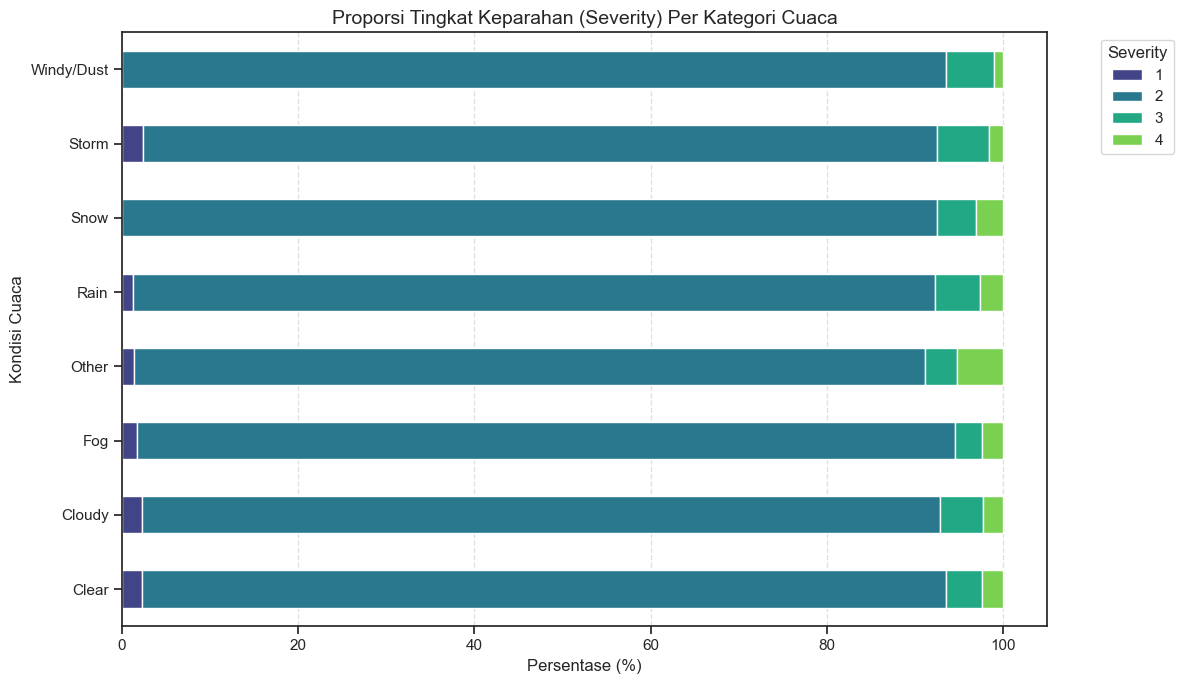

In [207]:
weather_severity_cross = pd.crosstab(df['Weather_Condition'], df['Severity'])

weather_severity_pct = weather_severity_cross.div(weather_severity_cross.sum(1), axis=0) * 100

weather_severity_pct.plot(kind='barh', stacked=True, figsize=(12, 7), 
                          color=sns.color_palette("viridis", 4))

plt.title('Proporsi Tingkat Keparahan (Severity) Per Kategori Cuaca', fontsize=14)
plt.xlabel('Persentase (%)')
plt.ylabel('Kondisi Cuaca')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

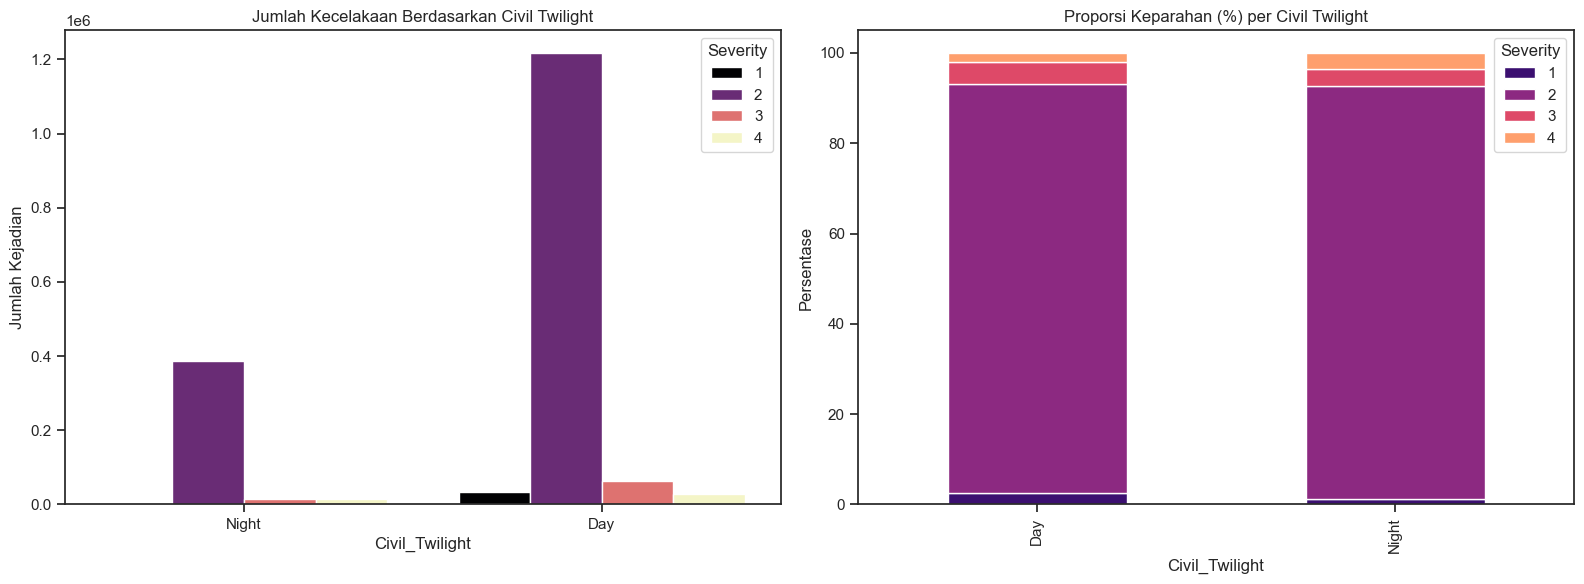

Tabel Persentase Severity per Civil Twilight:
Severity               1          2         3        4
Civil_Twilight                                        
Day             2.434183  90.803685  4.672162  2.08997
Night           1.243122  91.508571  3.632447  3.61586


In [209]:
df_twilight = df.dropna(subset=['Civil_Twilight'])

# 2. Membuat tabel kontingensi
twilight_severity = pd.crosstab(df_twilight['Civil_Twilight'], df_twilight['Severity'])

# 3. Normalisasi untuk mendapatkan persentase detail
twilight_pct = twilight_severity.div(twilight_severity.sum(1), axis=0) * 100

# 4. Plotting Side-by-Side (Jumlah vs Persentase)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Subplot A: Jumlah Kejadian (Absolute)
sns.countplot(data=df_twilight, x='Civil_Twilight', hue='Severity', palette='magma', ax=ax[0])
ax[0].set_title('Jumlah Kecelakaan Berdasarkan Civil Twilight')
ax[0].set_ylabel('Jumlah Kejadian')

# Subplot B: Proporsi (Persentase)
twilight_pct.plot(kind='bar', stacked=True, color=sns.color_palette("magma", 4), ax=ax[1])
ax[1].set_title('Proporsi Keparahan (%) per Civil Twilight')
ax[1].set_ylabel('Persentase')
ax[1].legend(title='Severity', loc='upper right')

plt.tight_layout()
plt.show()

# Menampilkan angka persentase detailnya
print("Tabel Persentase Severity per Civil Twilight:")
print(twilight_pct)

insight:

# EDA Tahap 2

- Impute End_Time based on severity dan duration (dari data yang ada)
- Bikin kolom duration
- Impute Civil_Twilight based on Hour + State
- Impute kolom numerical based on Weather Condition and Start_Time
- Hapusin outlier yang ga mahok akal
- Menangani target kolom yang imbalance

In [193]:
# Impute End_Time
df['Duration'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
mean_duration = df.groupby('Severity')['Duration'].transform('mean')

mask = df['End_Time'].isna()
df.loc[mask, 'End_Time'] = df.loc[mask, 'Start_Time'] + pd.to_timedelta(mean_duration[mask], unit='m')

In [194]:
# Bikin kolom duration untuk mengetahui seberapa lama traffic menyebabkan kemacetan
df['Duration'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60

In [197]:
# Impute kolom Civil_Twilight
df['Month'] = df['Start_Time'].dt.month
df['Hour'] = df['Start_Time'].dt.hour

def get_mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

fallback_levels = [
    ['State', 'Month', 'Hour'],
    ['Timezone', 'Month', 'Hour'],
    ['Hour']
]

for level in fallback_levels:
    df['Civil_Twilight'] = df['Civil_Twilight'].fillna(
        df.groupby(level)['Civil_Twilight'].transform(get_mode)
    )


In [196]:
df.Civil_Twilight.isna().sum()

np.int64(0)